## Importaciones  y rutas

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
from IPython.display import display

from src.config import ProjectConfig
from src.data_prep import WineDataLoader
from src.eda import WineEDA

ProjectConfig.create_directories()

## Cargar los Datasets

In [2]:
loader = WineDataLoader(
    red_wine_path=ProjectConfig.RED_WINE_FILE,
    white_wine_path=ProjectConfig.WHITE_WINE_FILE,
)

red_wine, white_wine = loader.load_data()

print("Dimensión del dataset tinto:", red_wine.shape)
print("Dimensión del dataset blanco:", white_wine.shape)

display(red_wine.head())
display(white_wine.head())

Dimensión del dataset tinto: (1599, 12)
Dimensión del dataset blanco: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Unificar DataSet

In [3]:
wine_data = loader.combine_data()

print(loader.get_dataset_summary())
display(wine_data.head())
display(wine_data.tail())

{'red_wines': 1599, 'white_wines': 4898, 'total_wines': 6497, 'total_columns': 13}


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white
6496,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6,white


## Tipos de Datos

In [4]:
wine_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


## Estadísticas basicas

In [7]:
display(wine_data.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,NaN,NaN,NaN,7.215307,1.296434,3.8,6.4,7.0,7.7,15.9
volatile acidity,6497.0,NaN,NaN,NaN,0.339666,0.164636,0.08,0.23,0.29,0.4,1.58
citric acid,6497.0,NaN,NaN,NaN,0.318633,0.145318,0.0,0.25,0.31,0.39,1.66
residual sugar,6497.0,NaN,NaN,NaN,5.443235,4.757804,0.6,1.8,3.0,8.1,65.8
chlorides,6497.0,NaN,NaN,NaN,0.056034,0.035034,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,NaN,NaN,NaN,30.525319,17.7494,1.0,17.0,29.0,41.0,289.0
total sulfur dioxide,6497.0,NaN,NaN,NaN,115.744574,56.521855,6.0,77.0,118.0,156.0,440.0
density,6497.0,NaN,NaN,NaN,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,NaN,NaN,NaN,3.218501,0.160787,2.72,3.11,3.21,3.32,4.01
sulphates,6497.0,NaN,NaN,NaN,0.531268,0.148806,0.22,0.43,0.51,0.6,2.0


## Valores faltantes y duplicados

In [8]:
eda = WineEDA(
    dataframe=wine_data,
    figures_directory=ProjectConfig.FIGURES_DIR,
)

display(eda.missing_values_table())
print(eda.duplicate_summary())

,missing_count,missing_percentage
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


{'duplicate_count': 1177, 'duplicate_percentage': 18.11605356318301}


## Distribución de calidad por tipo de vino

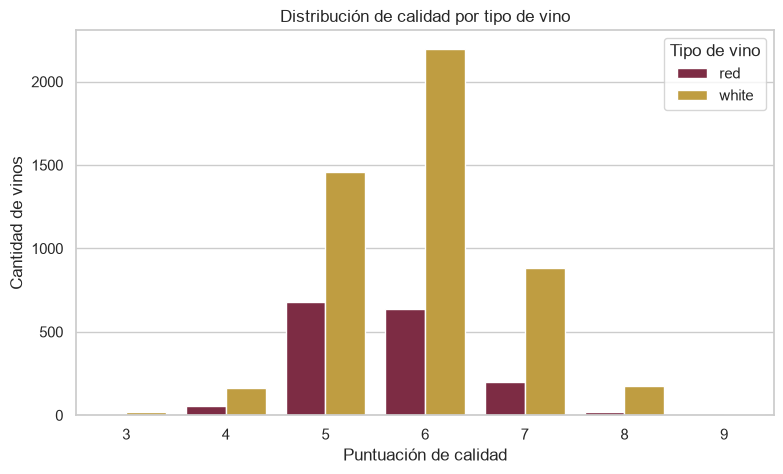

In [9]:
eda.quality_distribution()

## Distribucion de vinos por calidad mayor a  7

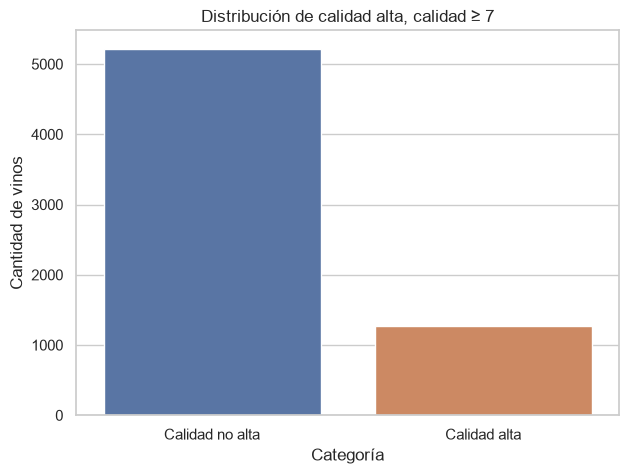

,category,count,percentage
0,Calidad no alta,5220,80.344775
1,Calidad alta,1277,19.655225


In [10]:
high_quality_distribution = (
    eda.high_quality_distribution(threshold=7)
)

display(high_quality_distribution)

## Distribuciones de las variables numericas

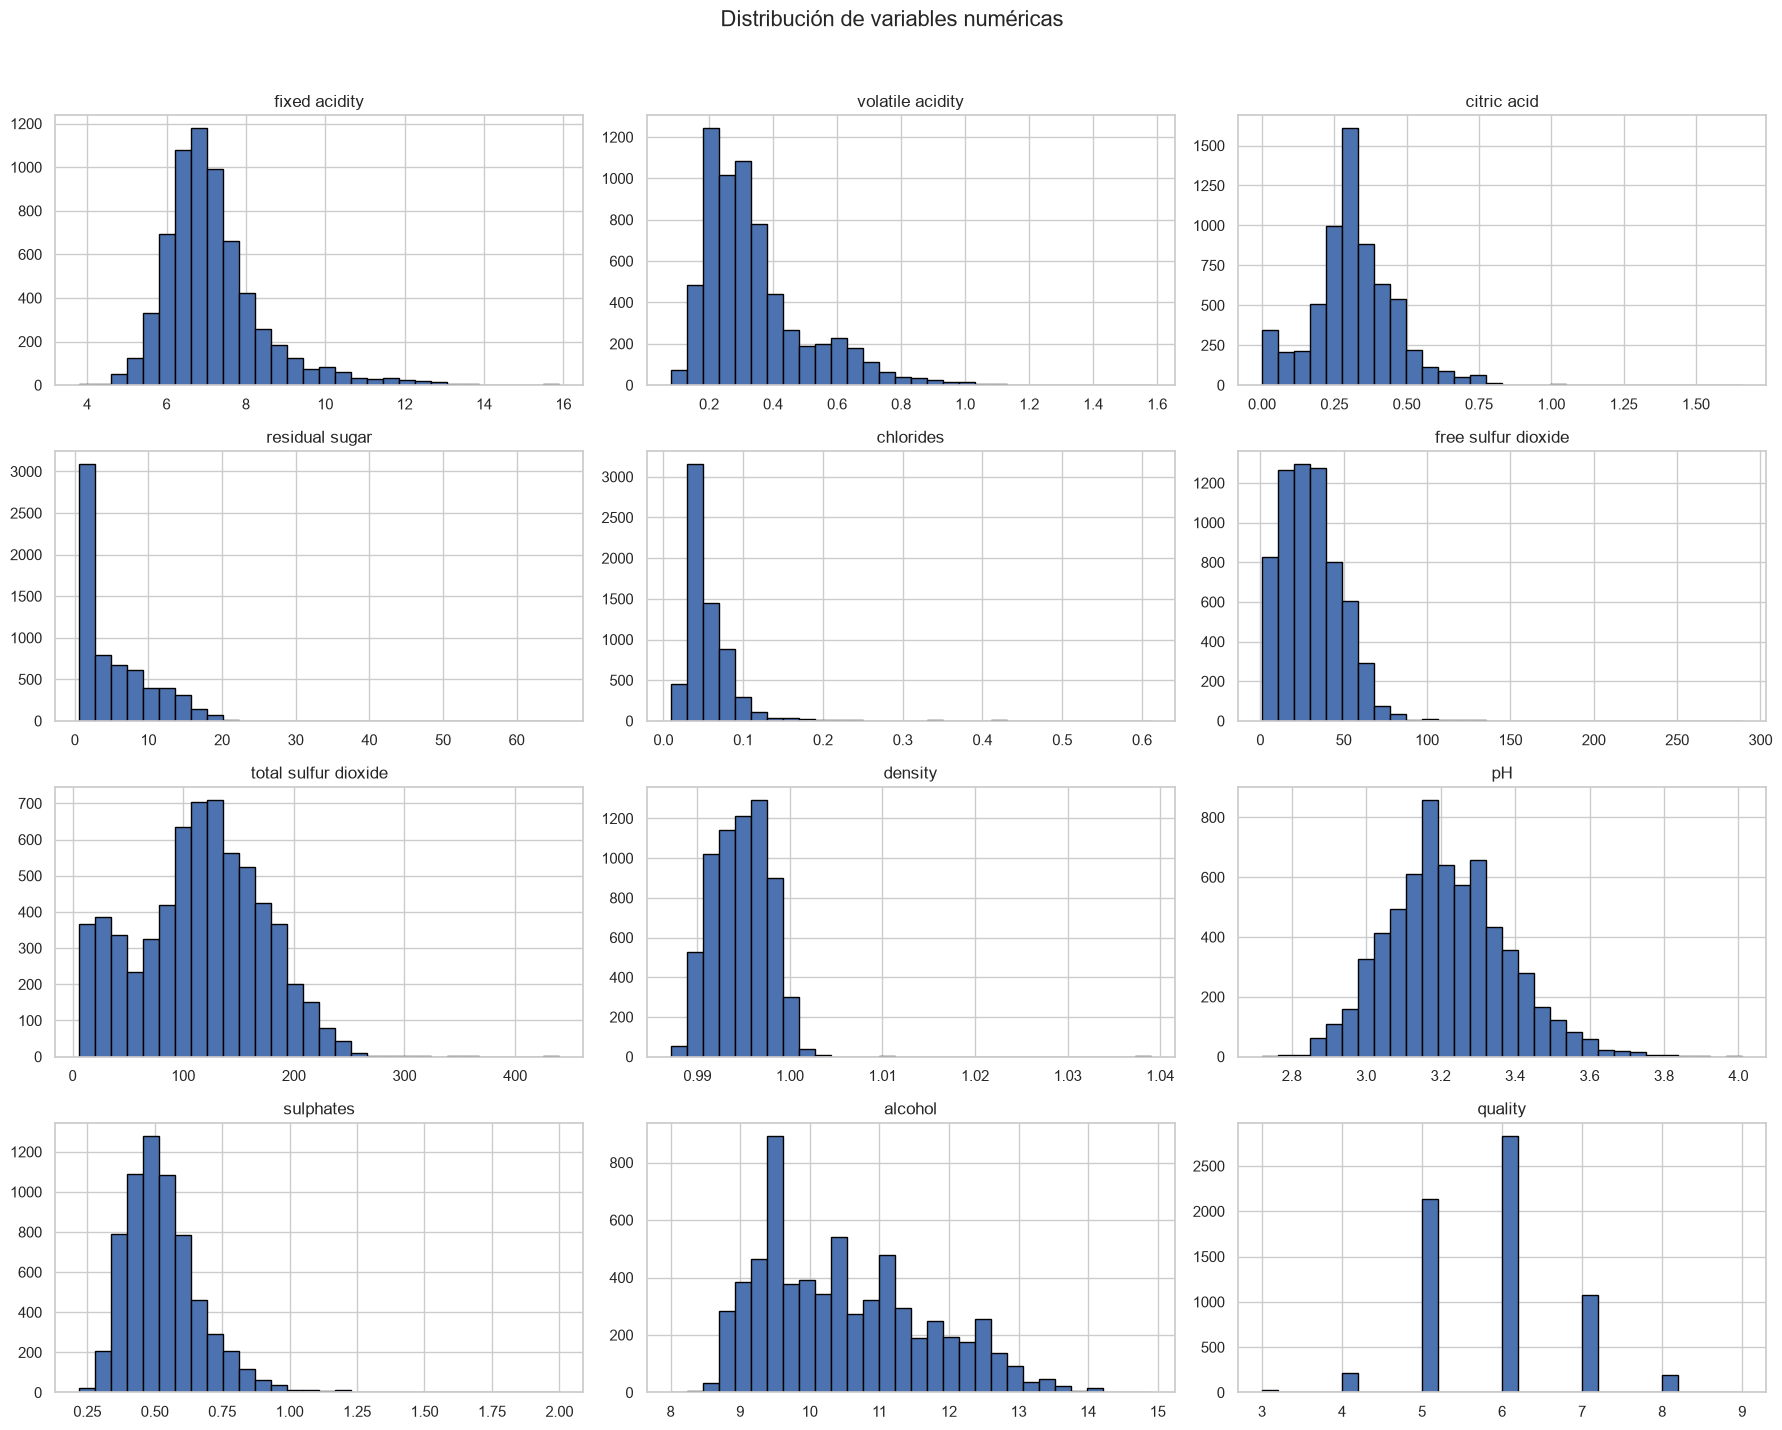

In [11]:
eda.numerical_distributions()

## Valores atípicos y boxplots

In [12]:
outliers_report = eda.detect_outliers_iqr()
display(outliers_report)

,variable,q1,q3,iqr,lower_limit,upper_limit,outlier_count,outlier_percentage
2,citric acid,0.25000,0.39000,0.14000,0.040000,0.600000,509,7.834385
1,volatile acidity,0.23000,0.40000,0.17000,-0.025000,0.655000,377,5.802678
0,fixed acidity,6.40000,7.70000,1.30000,4.450000,9.650000,357,5.494844
4,chlorides,0.03800,0.06500,0.02700,-0.002500,0.105500,286,4.402032
9,sulphates,0.43000,0.60000,0.17000,0.175000,0.855000,191,2.939818
3,residual sugar,1.80000,8.10000,6.30000,-7.650000,17.550000,118,1.816223
8,pH,3.11000,3.32000,0.21000,2.795000,3.635000,73,1.123596
5,free sulfur dioxide,17.00000,41.00000,24.00000,-19.000000,77.000000,62,0.954287
6,total sulfur dioxide,77.00000,156.00000,79.00000,-41.500000,274.500000,10,0.153917
7,density,0.99234,0.99699,0.00465,0.985365,1.003965,3,0.046175


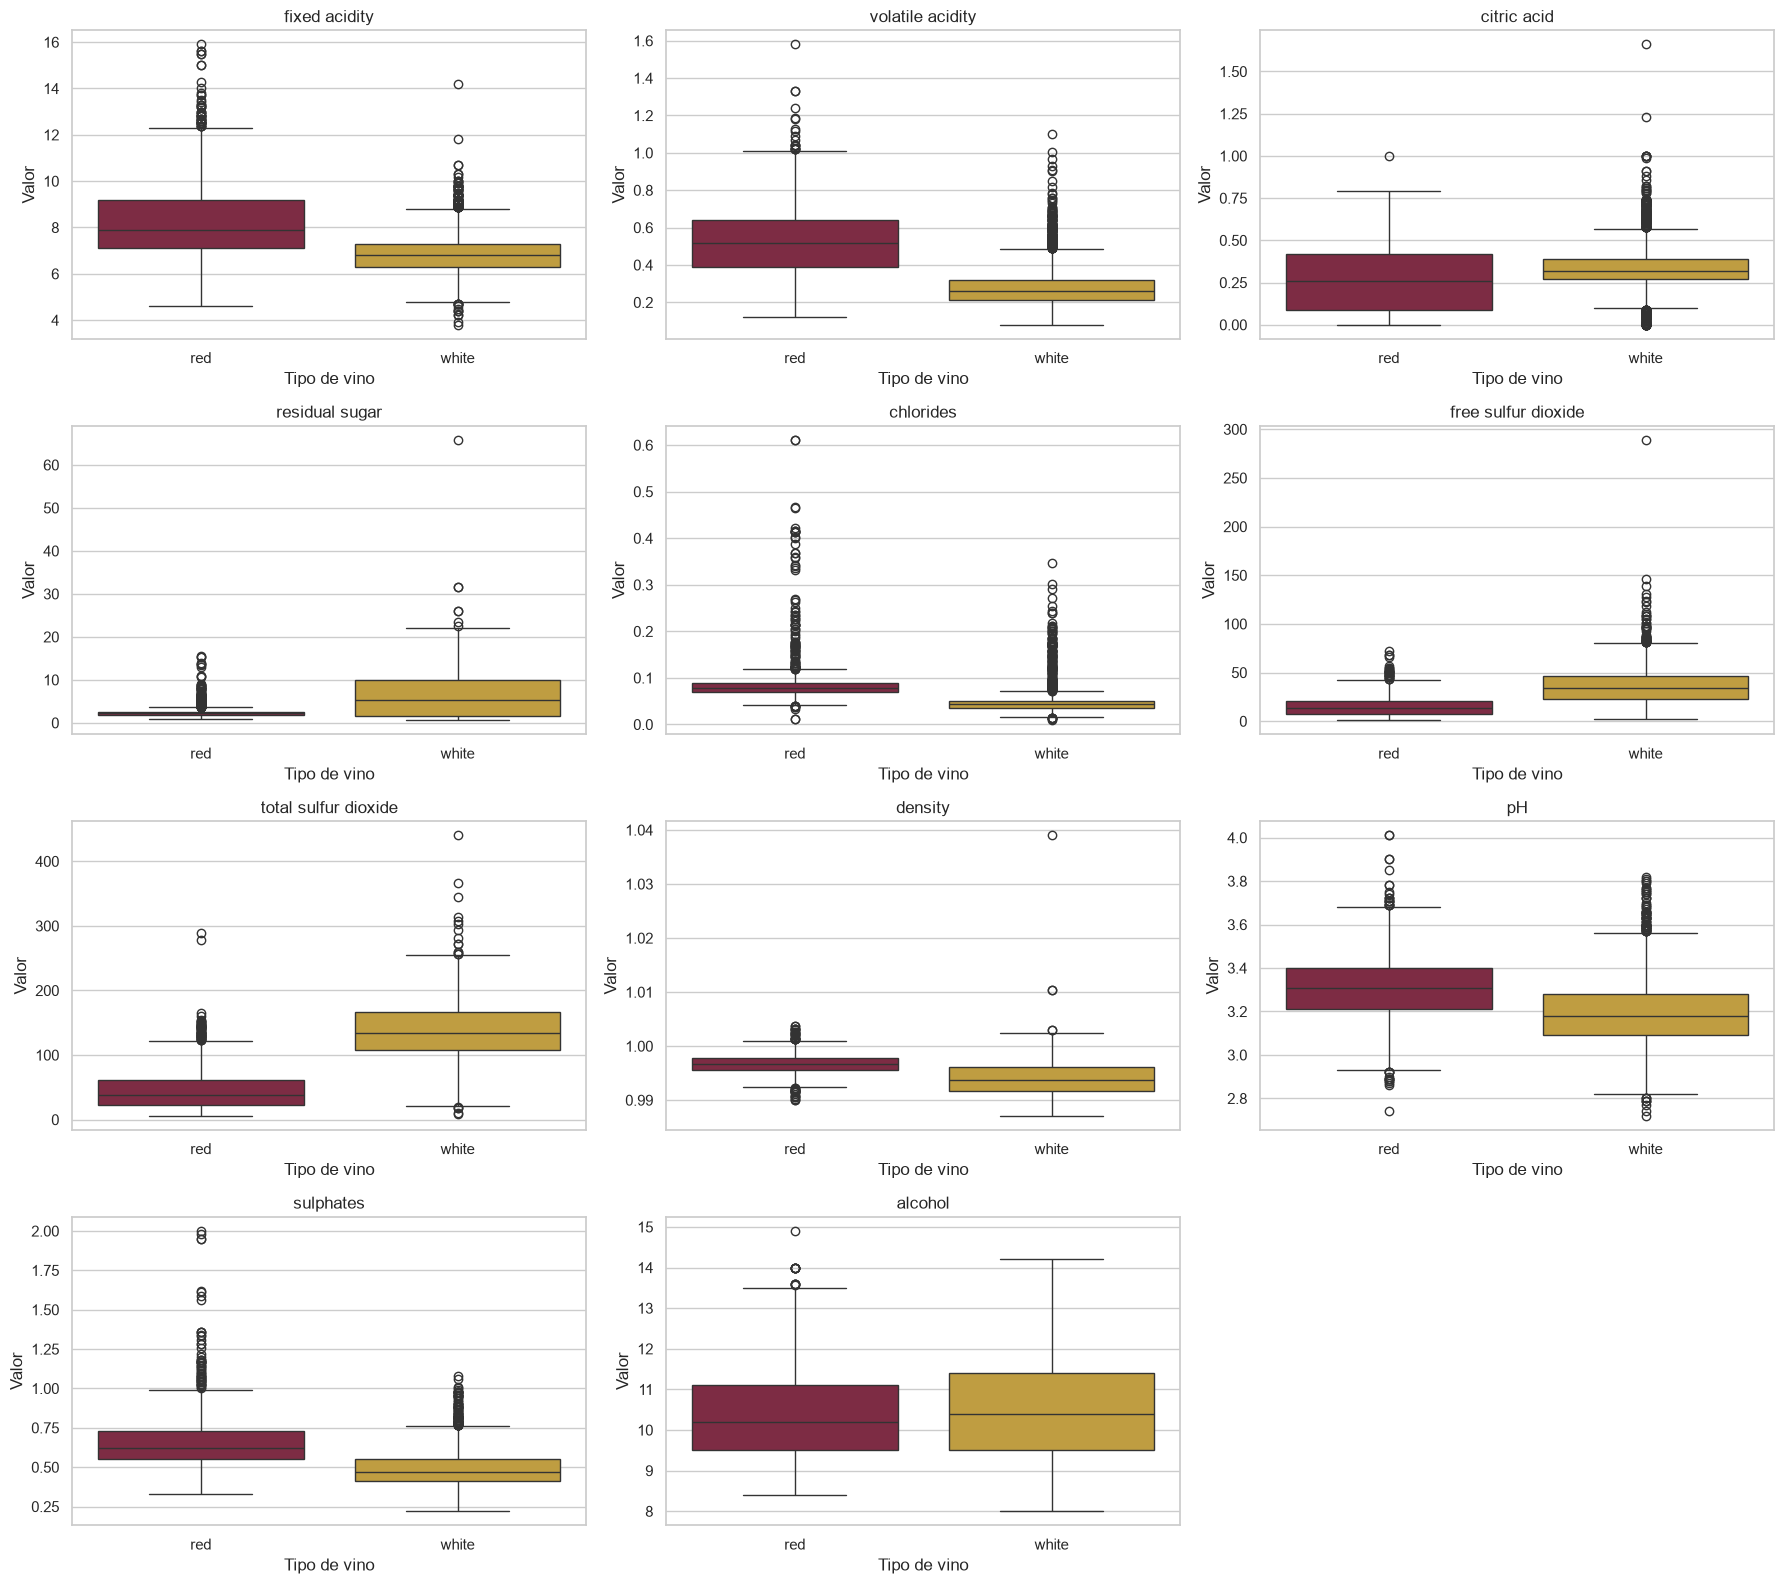

In [13]:
eda.boxplots_by_wine_type()

## Correlaciones - matrices

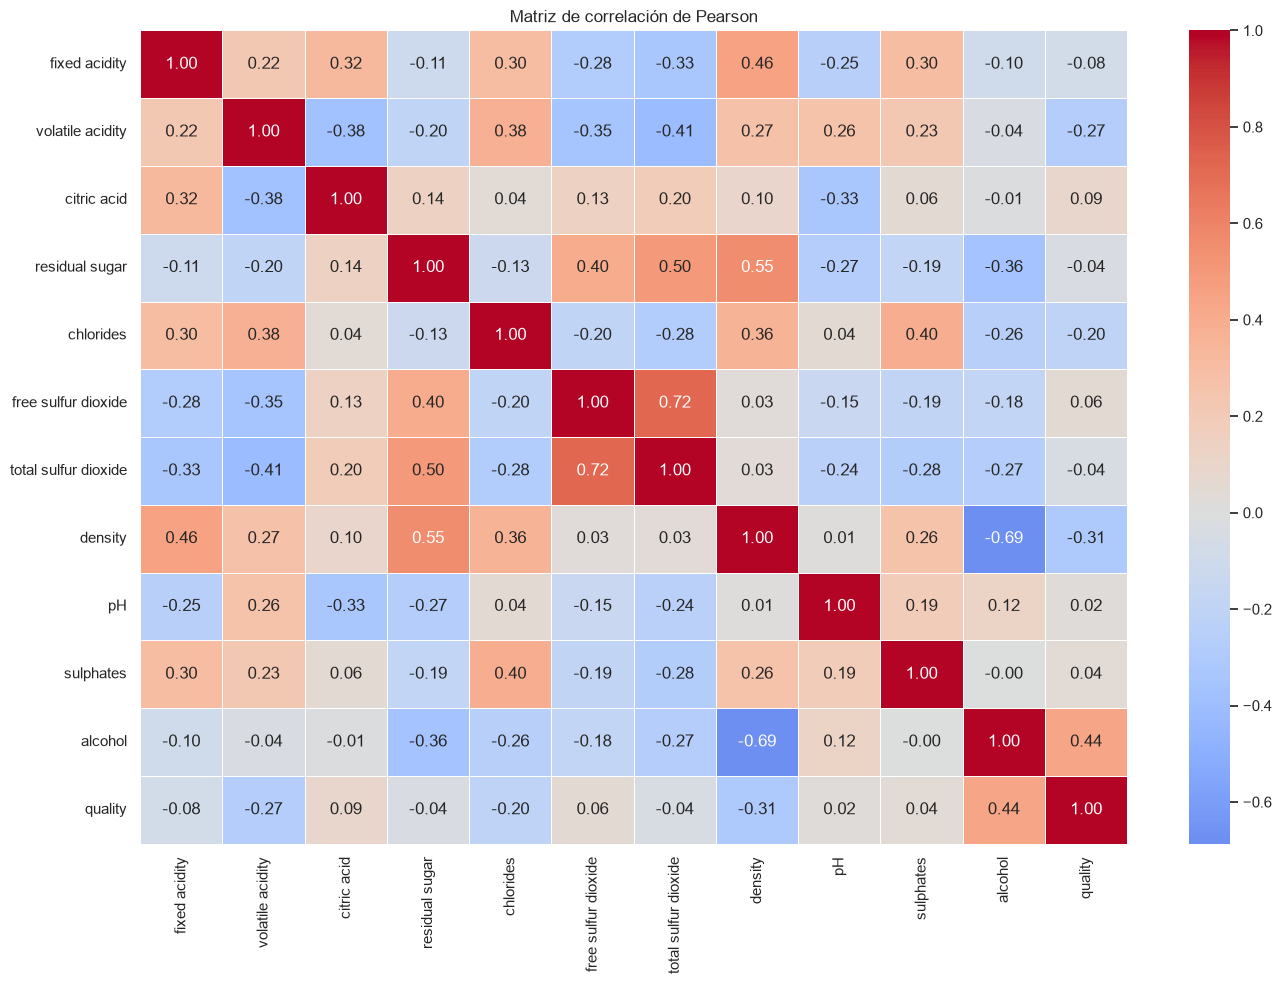

In [14]:
correlation_matrix = eda.correlation_matrix()

## Correlación de cada variables con la calidad

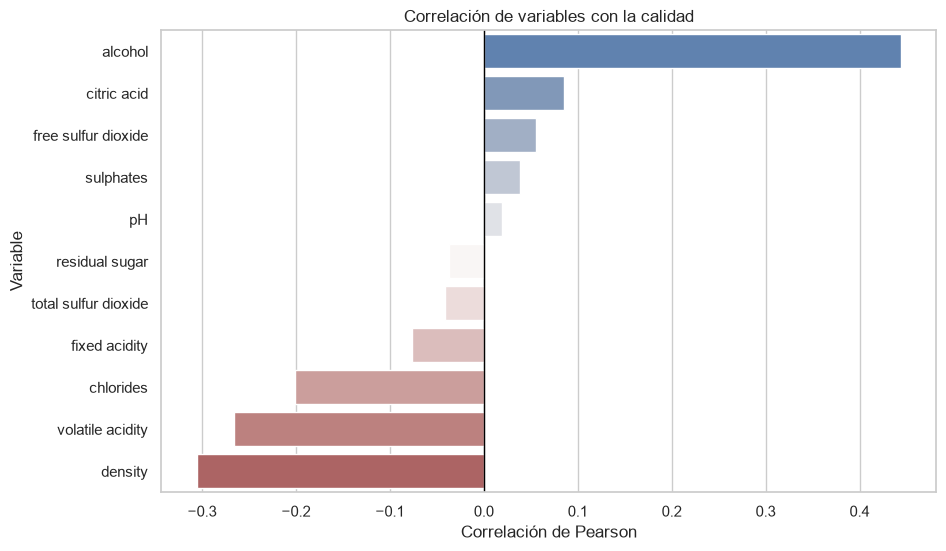

,correlation
alcohol,0.444319
citric acid,0.085532
free sulfur dioxide,0.055463
sulphates,0.038485
pH,0.019506
residual sugar,-0.036980
total sulfur dioxide,-0.041385
fixed acidity,-0.076743
chlorides,-0.200666
volatile acidity,-0.265699


In [15]:
quality_correlations = eda.quality_correlations()
display(quality_correlations.to_frame("correlation"))

## Comparación de cada variable de Tintos vs Blancos

In [16]:
wine_type_comparison = eda.compare_wine_types()
display(wine_type_comparison)

wine_type,red,white
fixed acidity,8.319637,6.854788
volatile acidity,0.527821,0.278241
citric acid,0.270976,0.334192
residual sugar,2.538806,6.391415
chlorides,0.087467,0.045772
free sulfur dioxide,15.874922,35.308085
total sulfur dioxide,46.467792,138.360657
density,0.996747,0.994027
pH,3.311113,3.188267
sulphates,0.658149,0.489847


## Guardar los Datos ya unificados

In [17]:
loader.save_combined_data(
    ProjectConfig.COMBINED_DATA_FILE
)

print(
    "Dataset unificado guardado en:",
    ProjectConfig.COMBINED_DATA_FILE,
)

Dataset unificado guardado en: C:\Proyecto_D_Calidad_Vino\data\processed\winequality-combined.csv


# Conclusiones del análisis exploratorio
